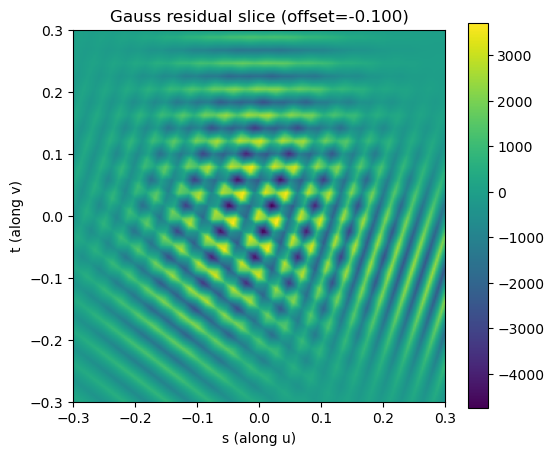

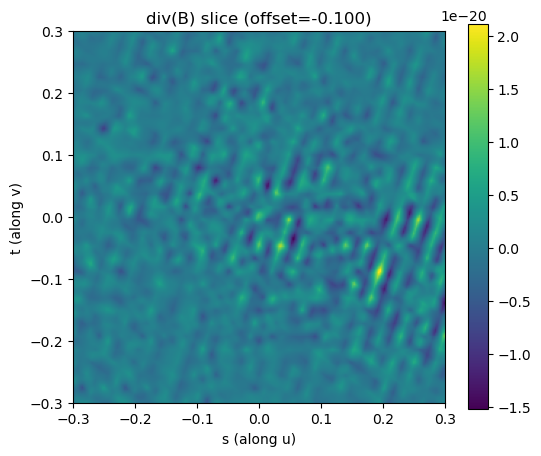

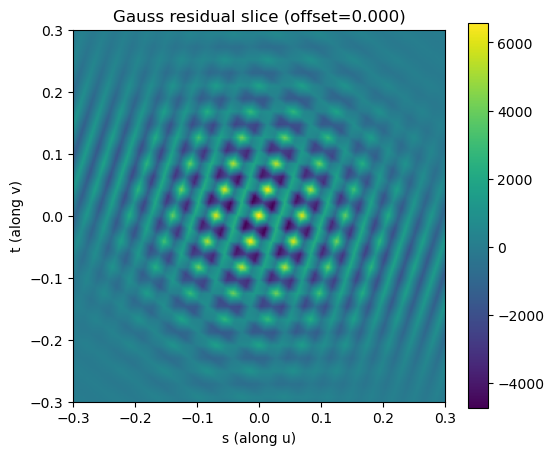

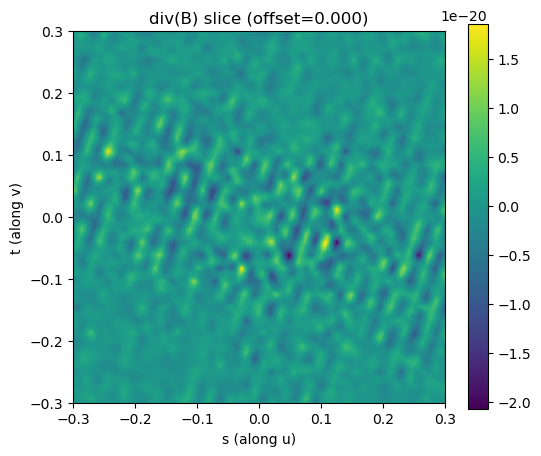

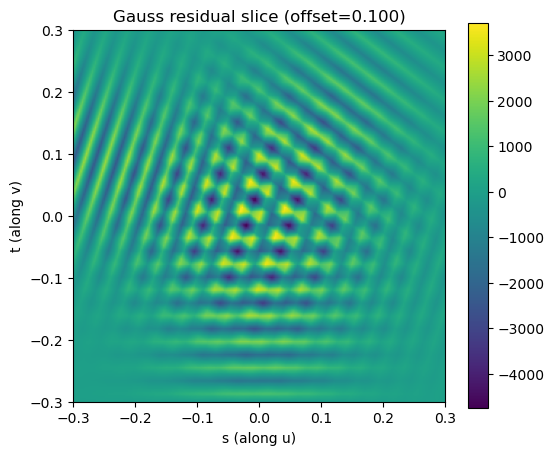

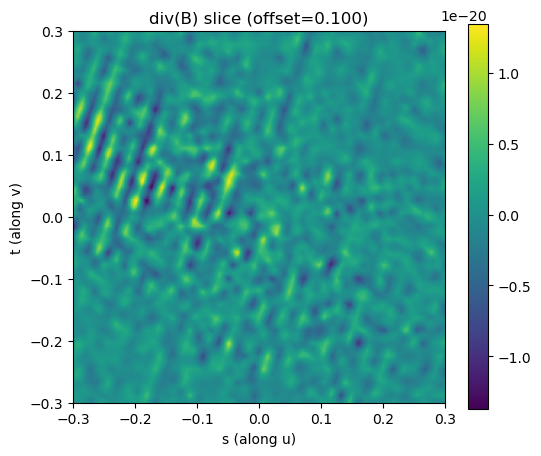

Done. You can call visualize_residual_slices(point, normal, offsets, width, npix, L) with your own inputs.


In [1]:
#rahul/4.Oct.2025: Initial Data in Maxwell's field
# This notebook constructs E and B fields on a periodic 3D grid (as before),
# computes Gauss and ∇·B residuals, and provides a function to visualize
# plane slices through a given point with a specified normal vector.
import numpy as np
import matplotlib.pyplot as plt

# ---------- Grid and spectral utilities ----------
def make_grid(n=64, L=1.0):
    x = np.linspace(0, L, n, endpoint=False)
    y = np.linspace(0, L, n, endpoint=False)
    z = np.linspace(0, L, n, endpoint=False)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    dx = L / n
    kx = 2*np.pi * np.fft.fftfreq(n, d=dx)
    ky = 2*np.pi * np.fft.fftfreq(n, d=dx)
    kz = 2*np.pi * np.fft.fftfreq(n, d=dx)
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
    K2 = KX**2 + KY**2 + KZ**2
    return (X, Y, Z), (KX, KY, KZ, K2), dx, L

def fftn(f):  return np.fft.fftn(f)
def ifftn(F): return np.fft.ifftn(F)

def grad_spectral(phi, KX, KY, KZ):
    Phi = fftn(phi)
    gx = np.real(ifftn(1j*KX * Phi))
    gy = np.real(ifftn(1j*KY * Phi))
    gz = np.real(ifftn(1j*KZ * Phi))
    return gx, gy, gz

def div_spectral(vx, vy, vz, KX, KY, KZ):
    Vx, Vy, Vz = fftn(vx), fftn(vy), fftn(vz)
    div = 1j*KX*Vx + 1j*KY*Vy + 1j*KZ*Vz
    return np.real(ifftn(div))

def curl_spectral(vx, vy, vz, KX, KY, KZ):
    Vx, Vy, Vz = fftn(vx), fftn(vy), fftn(vz)
    cx = 1j*(KY*Vz - KZ*Vy)
    cy = 1j*(KZ*Vx - KX*Vz)
    cz = 1j*(KX*Vy - KY*Vx)
    cx, cy, cz = np.real(ifftn(cx)), np.real(ifftn(cy)), np.real(ifftn(cz))
    return cx, cy, cz

def solve_phi_from_rho(rho, K2, eps0=8.8541878128e-12):
    R = fftn(rho)
    Phi = np.zeros_like(R, dtype=complex)
    mask = K2 != 0
    Phi[mask] = R[mask] / (eps0 * K2[mask])
    Phi[~mask] = 0.0
    phi = np.real(ifftn(Phi))
    return phi

def solve_A_from_j(jx, jy, jz, KX, KY, KZ, K2, mu0=4e-7*np.pi):
    Jx, Jy, Jz = fftn(jx), fftn(jy), fftn(jz)
    k2 = K2
    mask = k2 != 0

    with np.errstate(divide='ignore', invalid='ignore'):
        kx_over_k2 = np.zeros_like(KX);  kx_over_k2[mask] = KX[mask]/k2[mask]
        ky_over_k2 = np.zeros_like(KY);  ky_over_k2[mask] = KY[mask]/k2[mask]
        kz_over_k2 = np.zeros_like(KZ);  kz_over_k2[mask] = KZ[mask]/k2[mask]

    kJ = KX*Jx + KY*Jy + KZ*Jz
    JTx = Jx - kx_over_k2 * kJ
    JTy = Jy - ky_over_k2 * kJ
    JTz = Jz - kz_over_k2 * kJ

    Ax = np.zeros_like(Jx, dtype=complex)
    Ay = np.zeros_like(Jy, dtype=complex)
    Az = np.zeros_like(Jz, dtype=complex)
    Ax[mask] = -mu0 * JTx[mask] / k2[mask]
    Ay[mask] = -mu0 * JTy[mask] / k2[mask]
    Az[mask] = -mu0 * JTz[mask] / k2[mask]
    Ax[~mask] = Ay[~mask] = Az[~mask] = 0.0

    ax = np.real(ifftn(Ax)); ay = np.real(ifftn(Ay)); az = np.real(ifftn(Az))
    return ax, ay, az

def compute_E_and_B(rho, jx, jy, jz, KX, KY, KZ, K2, eps0=8.8541878128e-12, mu0=4e-7*np.pi):
    phi = solve_phi_from_rho(rho, K2, eps0=eps0)
    Ex, Ey, Ez = (-g for g in grad_spectral(phi, KX, KY, KZ))
    ax, ay, az = solve_A_from_j(jx, jy, jz, KX, KY, KZ, K2, mu0=mu0)
    Bx, By, Bz = curl_spectral(ax, ay, az, KX, KY, KZ)
    return (Ex, Ey, Ez), (Bx, By, Bz)

# ---------- Build a sample field ----------
n, L = 64, 1.0
(X, Y, Z), (KX, KY, KZ, K2), dx, L = make_grid(n=n, L=L)

# Charge density (zero-mean Gaussian) and divergence-free current
x0, y0, z0 = 0.5*L, 0.5*L, 0.5*L
sigma = 0.10*L
r2 = (X-x0)**2 + (Y-y0)**2 + (Z-z0)**2
rho = np.exp(-r2/(2*sigma**2))
rho -= rho.mean()

f = np.exp(-r2/(2*(0.12*L)**2))
fx, fy, fz = grad_spectral(f, KX, KY, KZ)
jx, jy, jz =  fy, -fx, np.zeros_like(f)

(Ex, Ey, Ez), (Bx, By, Bz) = compute_E_and_B(rho, jx, jy, jz, KX, KY, KZ, K2)

eps0 = 8.8541878128e-12
divE = div_spectral(Ex, Ey, Ez, KX, KY, KZ)
divB = div_spectral(Bx, By, Bz, KX, KY, KZ)
gauss_residual = divE - rho/eps0

# ---------- Trilinear interpolation on periodic grid ----------
def wrap_index(i, n):
    return i % n

def sample_trilinear_periodic(field, x, y, z, L):
    """
    field: (n,n,n) array defined on cell centers at coordinates [0, L) periodic
    x,y,z: arrays of coordinates to sample (same shape)
    returns: sampled values with same shape
    """
    n = field.shape[0]
    dx = L / n
    # Map to grid units
    gx = (x / dx) % n
    gy = (y / dx) % n
    gz = (z / dx) % n

    i0 = np.floor(gx).astype(int)
    j0 = np.floor(gy).astype(int)
    k0 = np.floor(gz).astype(int)

    i1 = (i0 + 1) % n
    j1 = (j0 + 1) % n
    k1 = (k0 + 1) % n

    tx = gx - i0
    ty = gy - j0
    tz = gz - k0

    c000 = field[i0, j0, k0]
    c100 = field[i1, j0, k0]
    c010 = field[i0, j1, k0]
    c110 = field[i1, j1, k0]
    c001 = field[i0, j0, k1]
    c101 = field[i1, j0, k1]
    c011 = field[i0, j1, k1]
    c111 = field[i1, j1, k1]

    c00 = c000*(1-tx) + c100*tx
    c01 = c001*(1-tx) + c101*tx
    c10 = c010*(1-tx) + c110*tx
    c11 = c011*(1-tx) + c111*tx

    c0 = c00*(1-ty) + c10*ty
    c1 = c01*(1-ty) + c11*ty

    c = c0*(1-tz) + c1*tz
    return c

# ---------- Plane slice sampling ----------
def orthonormal_basis_from_normal(nvec):
    n = np.asarray(nvec, dtype=float)
    n /= np.linalg.norm(n) + 1e-30
    # Choose an arbitrary vector not parallel to n
    a = np.array([1.0, 0.0, 0.0])
    if abs(np.dot(a, n)) > 0.9:
        a = np.array([0.0, 1.0, 0.0])
    u = np.cross(n, a)
    u /= np.linalg.norm(u) + 1e-30
    v = np.cross(n, u)
    v /= np.linalg.norm(v) + 1e-30
    return n, u, v

def sample_plane(field, point, normal, width=0.5, npix=256, offset=0.0, L=1.0):
    """
    Sample 'field' on a plane through 'point' displaced by 'offset' along 'normal'.
    Plane coordinates: r(s,t) = (point + offset*n) + s*u + t*v, with s,t in [-width/2, width/2]
    """
    n, u, v = orthonormal_basis_from_normal(normal)
    s = np.linspace(-width/2, width/2, npix)
    t = np.linspace(-width/2, width/2, npix)
    S, T = np.meshgrid(s, t, indexing='ij')
    origin = np.asarray(point) + offset * n
    Xp = origin[0] + S*u[0] + T*v[0]
    Yp = origin[1] + S*u[1] + T*v[1]
    Zp = origin[2] + S*u[2] + T*v[2]
    # Wrap coordinates into [0, L)
    Xp = Xp % L; Yp = Yp % L; Zp = Zp % L
    return sample_trilinear_periodic(field, Xp, Yp, Zp, L), S, T

def visualize_residual_slices(point, normal, offsets, width=0.6, npix=256, L=1.0):
    """
    For each offset along 'normal', show images of Gauss residual and divB residual
    on the plane slice.
    """
    for off in offsets:
        gauss_slice, S, T = sample_plane(gauss_residual, point, normal, width=width, npix=npix, offset=off, L=L)
        divB_slice, _, _ = sample_plane(divB, point, normal, width=width, npix=npix, offset=off, L=L)

        plt.figure(figsize=(6,5))
        plt.imshow(gauss_slice.T, origin='lower', extent=[S.min(), S.max(), T.min(), T.max()], aspect='equal')
        plt.colorbar()
        plt.title(f"Gauss residual slice (offset={off:.3f})")
        plt.xlabel("s (along u)")
        plt.ylabel("t (along v)")
        plt.show()

        plt.figure(figsize=(6,5))
        plt.imshow(divB_slice.T, origin='lower', extent=[S.min(), S.max(), T.min(), T.max()], aspect='equal')
        plt.colorbar()
        plt.title(f"div(B) slice (offset={off:.3f})")
        plt.xlabel("s (along u)")
        plt.ylabel("t (along v)")
        plt.show()

# ---------- Demo: slices through the Gaussian center with a tilted normal ----------
point = (0.5*L, 0.5*L, 0.5*L)
normal = (1.0, 1.0, 0.5)  # any orientation
offsets = [-0.10, 0.0, 0.10]  # three nearby planes
visualize_residual_slices(point, normal, offsets, width=0.6, npix=256, L=L)

print("Done. You can call visualize_residual_slices(point, normal, offsets, width, npix, L) with your own inputs.")

Diagnostics:
  ||div(E) - rho/eps0||_∞ = 203558421628.03958
  ||div(B)||_∞            = 238.6567674779619


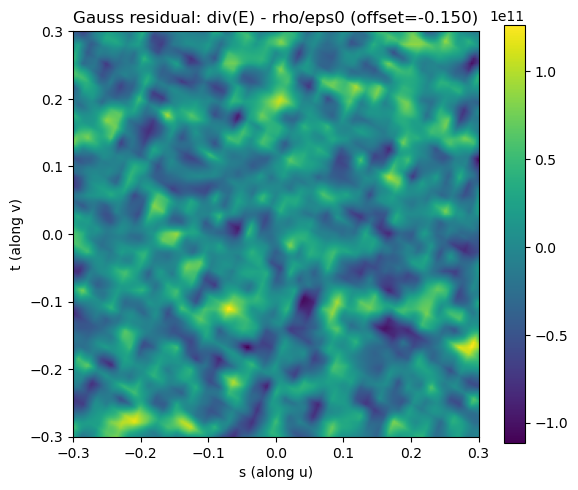

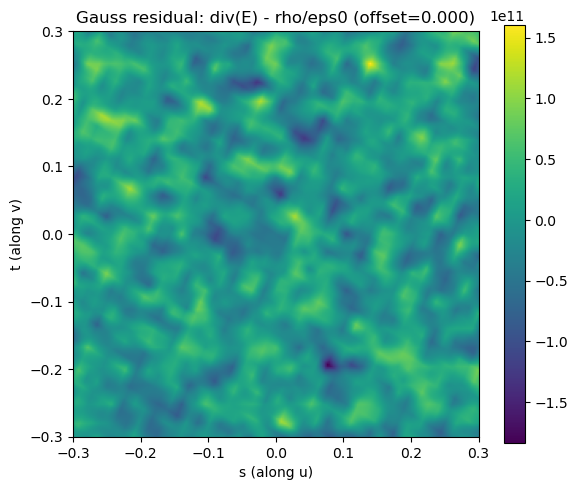

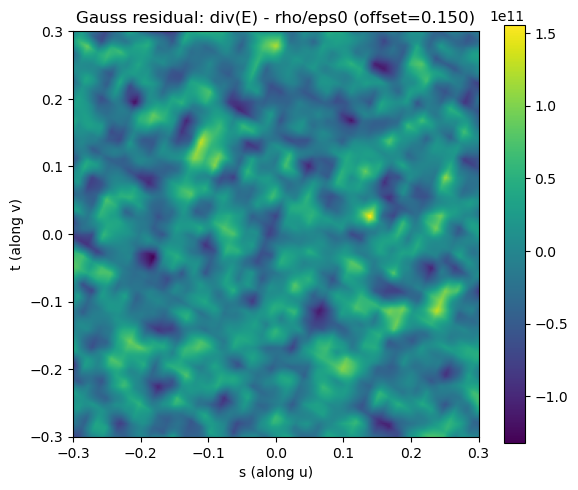

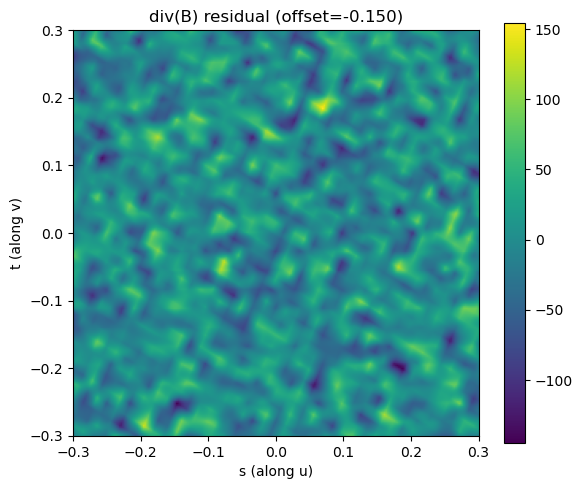

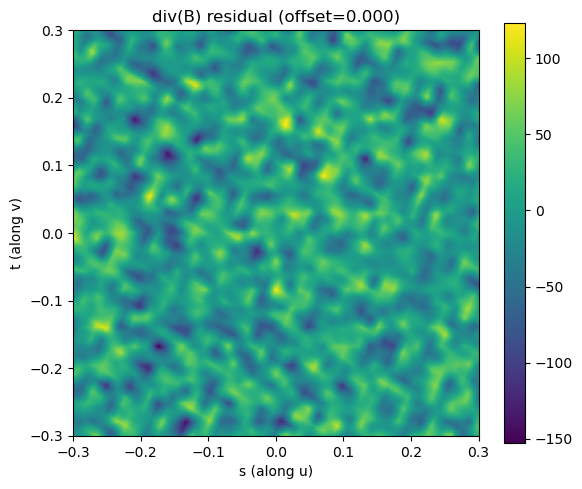

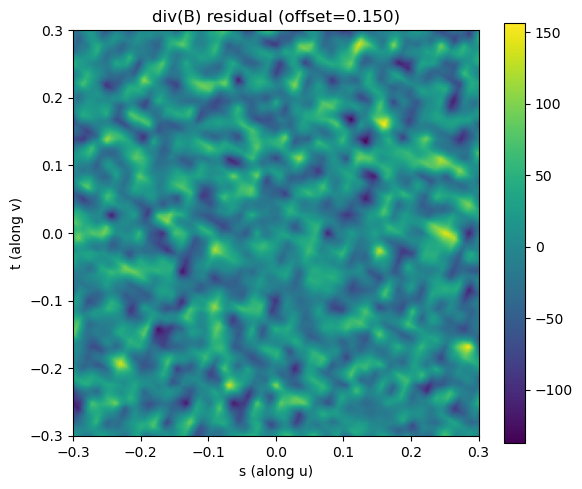

Done. Modify 'point', 'normal', and 'offsets' to explore different slices.


In [2]:
# Random E, B, and rho on a periodic 3D grid; compute div(E), div(B) and
# visualize residual slices: (div(E) - rho/eps0) and div(B).
#
# Notes:
# - Uses spectral derivatives (FFT) for accuracy on a periodic domain.
# - Random fields are smoothed in k-space to avoid grid-scale noise.
# - Slices are planes through a chosen point with an arbitrary normal.
import numpy as np
import matplotlib.pyplot as plt

# ---------- Grid and spectral utilities ----------
def make_grid(n=64, L=1.0):
    x = np.linspace(0, L, n, endpoint=False)
    y = np.linspace(0, L, n, endpoint=False)
    z = np.linspace(0, L, n, endpoint=False)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    dx = L / n
    kx = 2*np.pi * np.fft.fftfreq(n, d=dx)
    ky = 2*np.pi * np.fft.fftfreq(n, d=dx)
    kz = 2*np.pi * np.fft.fftfreq(n, d=dx)
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
    K2 = KX**2 + KY**2 + KZ**2
    return (X, Y, Z), (KX, KY, KZ, K2), dx, L

def fftn(f):  return np.fft.fftn(f)
def ifftn(F): return np.fft.ifftn(F)

def div_spectral(vx, vy, vz, KX, KY, KZ):
    Vx, Vy, Vz = fftn(vx), fftn(vy), fftn(vz)
    div = 1j*KX*Vx + 1j*KY*Vy + 1j*KZ*Vz
    return np.real(ifftn(div))

# ---------- Build random, smooth fields on the same grid ----------
n, L = 64, 1.0
(X, Y, Z), (KX, KY, KZ, K2), dx, L = make_grid(n=n, L=L)

# Low-pass filter in k-space to smooth fields
kmax = np.sqrt((KX**2 + KY**2 + KZ**2).max())
k0 = 0.35 * kmax
LP = np.exp(-K2 / (2.0*k0*k0))

# Random rho (zero-mean) and random vector fields for E and B, smoothed
rng = np.random.default_rng(42)
def smooth_random():
    F = fftn(rng.standard_normal((n, n, n)))
    return np.real(ifftn(F * LP))

rho = smooth_random()
rho -= rho.mean()  # remove net charge for periodicity

Ex = smooth_random(); Ey = smooth_random(); Ez = smooth_random()
Bx = smooth_random(); By = smooth_random(); Bz = smooth_random()

# ---------- Divergences in (x,y,z) space ----------
eps0 = 8.8541878128e-12
divE = div_spectral(Ex, Ey, Ez, KX, KY, KZ)
divB = div_spectral(Bx, By, Bz, KX, KY, KZ)

gauss_residual = divE - rho/eps0

print("Diagnostics:")
print("  ||div(E) - rho/eps0||_∞ =", float(np.abs(gauss_residual).max()))
print("  ||div(B)||_∞            =", float(np.abs(divB).max()))

# ---------- Plane slice sampling utilities ----------
def orthonormal_basis_from_normal(nvec):
    n = np.asarray(nvec, dtype=float)
    n /= np.linalg.norm(n) + 1e-30
    a = np.array([1.0, 0.0, 0.0])
    if abs(np.dot(a, n)) > 0.9:
        a = np.array([0.0, 1.0, 0.0])
    u = np.cross(n, a); u /= np.linalg.norm(u) + 1e-30
    v = np.cross(n, u); v /= np.linalg.norm(v) + 1e-30
    return n, u, v

def sample_trilinear_periodic(field, x, y, z, L):
    n = field.shape[0]
    dx = L / n
    gx = (x / dx) % n
    gy = (y / dx) % n
    gz = (z / dx) % n

    i0 = np.floor(gx).astype(int); j0 = np.floor(gy).astype(int); k0 = np.floor(gz).astype(int)
    i1 = (i0 + 1) % n;           j1 = (j0 + 1) % n;           k1 = (k0 + 1) % n

    tx = gx - i0; ty = gy - j0; tz = gz - k0

    c000 = field[i0, j0, k0]; c100 = field[i1, j0, k0]
    c010 = field[i0, j1, k0]; c110 = field[i1, j1, k0]
    c001 = field[i0, j0, k1]; c101 = field[i1, j0, k1]
    c011 = field[i0, j1, k1]; c111 = field[i1, j1, k1]

    c00 = c000*(1-tx) + c100*tx; c01 = c001*(1-tx) + c101*tx
    c10 = c010*(1-tx) + c110*tx; c11 = c011*(1-tx) + c111*tx

    c0 = c00*(1-ty) + c10*ty; c1 = c01*(1-ty) + c11*ty
    c = c0*(1-tz) + c1*tz
    return c

def sample_plane(field, point, normal, width=0.6, npix=256, offset=0.0, L=1.0):
    n, u, v = orthonormal_basis_from_normal(normal)
    s = np.linspace(-width/2, width/2, npix)
    t = np.linspace(-width/2, width/2, npix)
    S, T = np.meshgrid(s, t, indexing='ij')
    origin = np.asarray(point) + offset * n
    Xp = (origin[0] + S*u[0] + T*v[0]) % L
    Yp = (origin[1] + S*u[1] + T*v[1]) % L
    Zp = (origin[2] + S*u[2] + T*v[2]) % L
    return sample_trilinear_periodic(field, Xp, Yp, Zp, L), S, T

def visualize_residual_slices(residual_field, title_prefix, point, normal, offsets, width=0.6, npix=256, L=1.0):
    for off in offsets:
        plane_vals, S, T = sample_plane(residual_field, point, normal, width=width, npix=npix, offset=off, L=L)
        plt.figure(figsize=(6,5))
        plt.imshow(plane_vals.T, origin='lower', extent=[S.min(), S.max(), T.min(), T.max()], aspect='equal')
        plt.colorbar()
        plt.xlabel("s (along u)")
        plt.ylabel("t (along v)")
        plt.title(f"{title_prefix} (offset={off:.3f})")
        plt.tight_layout()
        plt.show()

# ---------- Plot slices of residuals ----------
point = (0.5*L, 0.5*L, 0.5*L)
normal = (1.0, 0.6, 0.3)  # arbitrary
offsets = [-0.15, 0.0, 0.15]

visualize_residual_slices(gauss_residual, "Gauss residual: div(E) - rho/eps0", point, normal, offsets, width=0.6, npix=256, L=L)
visualize_residual_slices(divB, "div(B) residual", point, normal, offsets, width=0.6, npix=256, L=L)

print("Done. Modify 'point', 'normal', and 'offsets' to explore different slices.")

Grid: 100x100 interior, spacing h=9.9010e-03
CG iterations: 1
L2 error ≈ 4.032e-05
L∞ error ≈ 8.061e-05
Final discrete energy J_h(u) ≈ -2.467600e+00


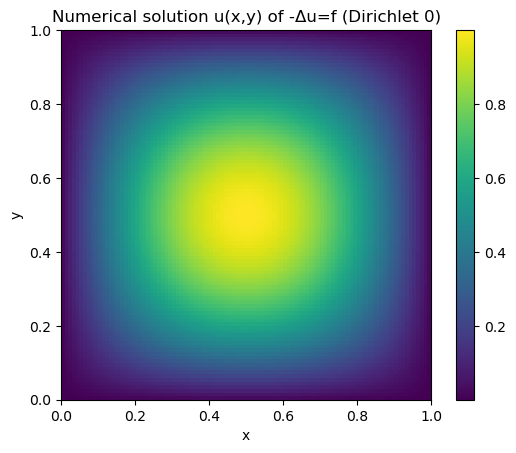

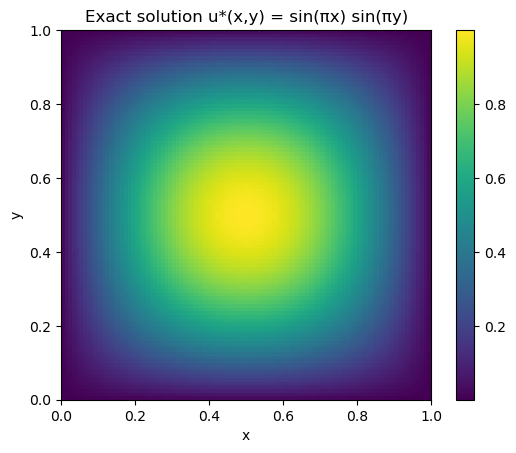

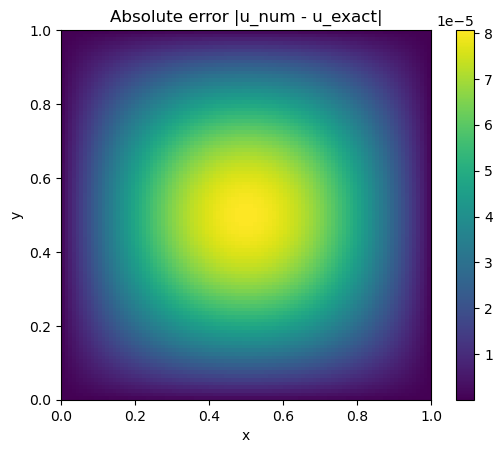

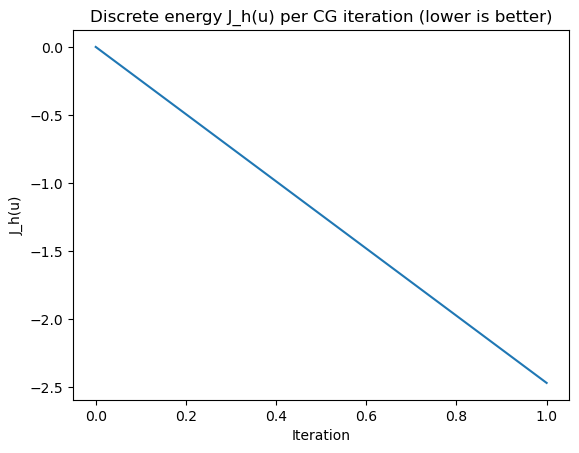

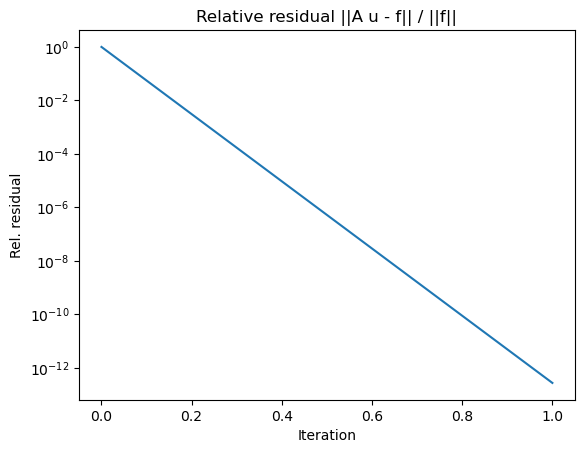

In [3]:
# Poisson equation via energy minimization on a unit square
# Problem: Solve -Δu = f in Ω=(0,1)^2 with u=0 on ∂Ω
# Variational form: minimize J(u) = ∫_Ω [1/2 |∇u|^2 - f u] dxdy
# Discretization: 5-point finite-difference (Dirichlet 0 on the boundary), solved by Conjugate Gradient
# Validation case: exact solution u*(x,y) = sin(πx) sin(πy), so f(x,y) = 2π^2 sin(πx) sin(πy)

import numpy as np
import matplotlib.pyplot as plt

# Grid
N = 100                    # interior points per dimension
h = 1.0/(N+1)              # grid spacing
x = np.linspace(h, 1-h, N) # interior grid
y = np.linspace(h, 1-h, N)
X, Y = np.meshgrid(x, y, indexing='ij')

# Right-hand side and exact solution
f = 2*(np.pi**2)*np.sin(np.pi*X)*np.sin(np.pi*Y)  # because -Δ sin(πx)sin(πy) = 2π^2 sin(πx)sin(πy)
u_true = np.sin(np.pi*X)*np.sin(np.pi*Y)

def apply_A(u):
    """
    Apply the discrete operator A ≈ -Δ with 5-point stencil and zero Dirichlet boundaries.
    A(u)_ij = (4 u_ij - u_{i-1,j} - u_{i+1,j} - u_{i,j-1} - u_{i,j+1})/h^2
    """
    up = np.pad(u, 1, mode='constant')  # pad with zeros for boundary
    Au = (4*up[1:-1,1:-1] - up[:-2,1:-1] - up[2:,1:-1] - up[1:-1,:-2] - up[1:-1,2:])/(h*h)
    return Au

def energy(u, f):
    """
    Discrete energy J_h(u) = 0.5 * <u, A u>_h - <u, f>_h,
    where <a,b>_h = h^2 * sum_ij a_ij b_ij is the trapezoid-like inner product.
    """
    Au = apply_A(u)
    return 0.5 * h*h * np.sum(u*Au) - h*h * np.sum(u*f)

def cg_solve(f, tol=1e-10, maxiter=5000):
    """
    Conjugate Gradient on A u = f, where A is SPD (discrete -Δ with Dirichlet BC).
    Works matrix-free via apply_A.
    Returns u, number of iterations, energy history, residual norm history.
    """
    u = np.zeros_like(f)
    r = f - apply_A(u)
    p = r.copy()
    rsold = np.sum(r*r)
    bnorm = np.sqrt(np.sum(f*f)) + 1e-30

    E_hist = [energy(u, f)]
    R_hist = [np.sqrt(rsold)/bnorm]

    for k in range(1, maxiter+1):
        Ap = apply_A(p)
        alpha = rsold / (np.sum(p*Ap) + 1e-30)
        u = u + alpha * p
        r = r - alpha * Ap
        rsnew = np.sum(r*r)
        E_hist.append(energy(u, f))
        R_hist.append(np.sqrt(rsnew)/bnorm)

        if np.sqrt(rsnew) <= tol * bnorm:
            return u, k, np.array(E_hist), np.array(R_hist)
        p = r + (rsnew/rsold) * p
        rsold = rsnew

    return u, k, np.array(E_hist), np.array(R_hist)

u_num, iters, E_hist, R_hist = cg_solve(f, tol=1e-8, maxiter=5000)

# Error metrics
err = u_num - u_true
l2_err = np.sqrt(h*h * np.sum(err*err))
linf_err = np.max(np.abs(err))

print(f"Grid: {N}x{N} interior, spacing h={h:.4e}")
print(f"CG iterations: {iters}")
print(f"L2 error ≈ {l2_err:.3e}")
print(f"L∞ error ≈ {linf_err:.3e}")
print(f"Final discrete energy J_h(u) ≈ {E_hist[-1]:.6e}")

# Visualization 1: numerical solution
plt.figure()
plt.imshow(u_num, origin='lower', extent=[0,1,0,1])
plt.title("Numerical solution u(x,y) of -Δu=f (Dirichlet 0)")
plt.colorbar()
plt.xlabel("x"); plt.ylabel("y")
plt.show()

# Visualization 2: exact solution
plt.figure()
plt.imshow(u_true, origin='lower', extent=[0,1,0,1])
plt.title("Exact solution u*(x,y) = sin(πx) sin(πy)")
plt.colorbar()
plt.xlabel("x"); plt.ylabel("y")
plt.show()

# Visualization 3: absolute error
plt.figure()
plt.imshow(np.abs(err), origin='lower', extent=[0,1,0,1])
plt.title("Absolute error |u_num - u_exact|")
plt.colorbar()
plt.xlabel("x"); plt.ylabel("y")
plt.show()

# Visualization 4: energy decrease (shows minimization)
plt.figure()
plt.plot(E_hist)
plt.title("Discrete energy J_h(u) per CG iteration (lower is better)")
plt.xlabel("Iteration"); plt.ylabel("J_h(u)")
plt.show()

# Visualization 5: relative residual norm
plt.figure()
plt.plot(R_hist)
plt.title("Relative residual ||A u - f|| / ||f||")
plt.xlabel("Iteration"); plt.ylabel("Rel. residual")
plt.yscale('log')
plt.show()



Visualizing different slices of the *original* fields...



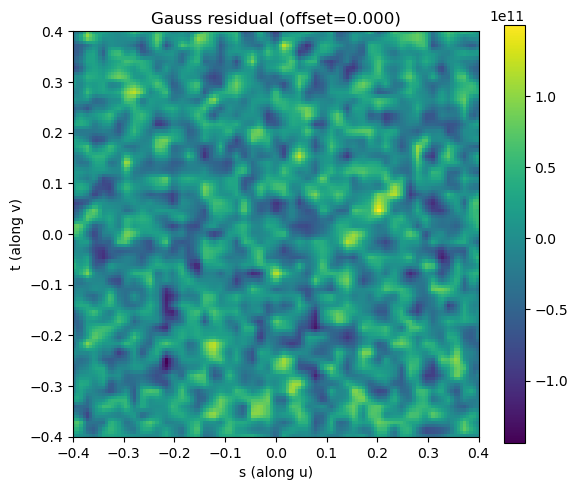

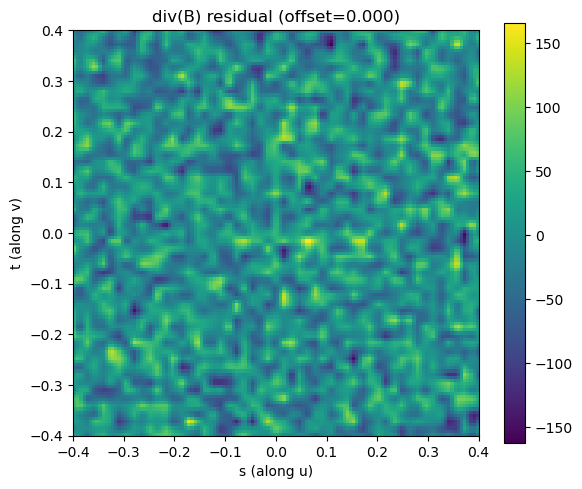

Done visualizing new slices.


In [4]:
# --- New cell for different slices (Corrected) ---

print("\n" + "="*50)
print("Visualizing different slices of the *original* fields...")
print("="*50 + "\n")

# Define new slice parameters
point_2 = (0.25*L, 0.25*L, 0.25*L) # A different point
normal_2 = (0.0, 0.0, 1.0)       # Slice parallel to the xy-plane
offsets_2 = [0.0]               # Just one slice at the point
width_2 = 0.8                   # A wider view

# ---
# THE FIX: Call the function from Cell 3 twice, specifying
# which residual field and title to use.
# ---

# 1. Plot the Gauss residual
visualize_residual_slices(
    gauss_residual,  # 1st arg: the field to plot
    "Gauss residual", # 2nd arg: the title prefix
    point_2,           # 3rd arg: point
    normal_2,          # 4th arg: normal
    offsets_2,         # 5th arg: offsets
    width=width_2,
    npix=128,
    L=L
)

# 2. Plot the div(B) residual
visualize_residual_slices(
    divB,            # 1st arg: the field to plot
    "div(B) residual", # 2nd arg: the title prefix
    point_2,           # 3rd arg: point
    normal_2,          # 4th arg: normal
    offsets_2,         # 5th arg: offsets
    width=width_2,
    npix=128,
    L=L
)

print("Done visualizing new slices.")

In [5]:
# --- Initial Conditions: Electrostatic Dipole ---

print("Setting up Electrostatic Dipole...")

# Define two points for the dipole
x_pos, y_pos, z_pos = 0.5*L, 0.5*L, 0.55*L
x_neg, y_neg, z_neg = 0.5*L, 0.5*L, 0.45*L
sigma_dipole = 0.05*L

# Positive charge
r2_pos = (X-x_pos)**2 + (Y-y_pos)**2 + (Z-z_pos)**2
rho_pos = np.exp(-r2_pos/(2*sigma_dipole**2))

# Negative charge
r2_neg = (X-x_neg)**2 + (Y-y_neg)**2 + (Z-z_neg)**2
rho_neg = -np.exp(-r2_neg/(2*sigma_dipole**2))

# Total charge density
rho_new = rho_pos + rho_neg
# rho_new -= rho_new.mean() # Good practice, though already balanced

# No current
jx_new = np.zeros_like(X)
jy_new = np.zeros_like(X)
jz_new = np.zeros_like(X)

# --- Compute new fields and residuals (add this after one of the blocks above) ---
print("Computing new E and B fields...")
(Ex_new, Ey_new, Ez_new), (Bx_new, By_new, Bz_new) = compute_E_and_B(
    rho_new, jx_new, jy_new, jz_new, KX, KY, KZ, K2
)

print("Computing new residuals...")
divE_new = div_spectral(Ex_new, Ey_new, Ez_new, KX, KY, KZ)
divB_new = div_spectral(Bx_new, By_new, Bz_new, KX, KY, KZ)

gauss_residual_new = divE_new - rho_new/eps0
divB_new_field = divB_new

print("New residual norms (should be small):")
print(f"  ||div(E) - rho/eps0||_∞ = {float(np.abs(gauss_residual_new).max())}")
print(f"  ||div(B)||_∞            = {float(np.abs(divB_new_field).max())}")

# --- Plot the new residuals (add this after the compute block) ---
print("Visualizing new residuals...")

point_vis = (0.5*L, 0.5*L, 0.5*L) # Center of the box
normal_vis = (0.0, 1.0, 0.0)     # Slice normal to y-axis
offsets_vis = [-0.1, 0.0, 0.1]

# Plot Gauss residual
visualize_residual_slices(
    gauss_residual_new,
    "NEW Gauss residual",
    point_vis, normal_vis, offsets_vis,
    width=0.6, npix=128, L=L
)

# Plot div(B) residual
visualize_residual_slices(
    divB_new_field,
    "NEW div(B) residual",
    point_vis, normal_vis, offsets_vis,
    width=0.6, npix=128, L=L
)

print("Done with new initial conditions.")

Setting up Electrostatic Dipole...


ValueError: operands could not be broadcast together with shapes (100,100) (64,64,64) 

Grid (X,Y,Z) reset to 64x64x64.
Setting up Electrostatic Dipole...
Computing new E and B fields...
Computing new residuals...
New residual norms (should be small):
  ||div(E) - rho/eps0||_∞ = 0.00185394287109375
  ||div(B)||_∞            = 0.0
Visualizing new residuals...


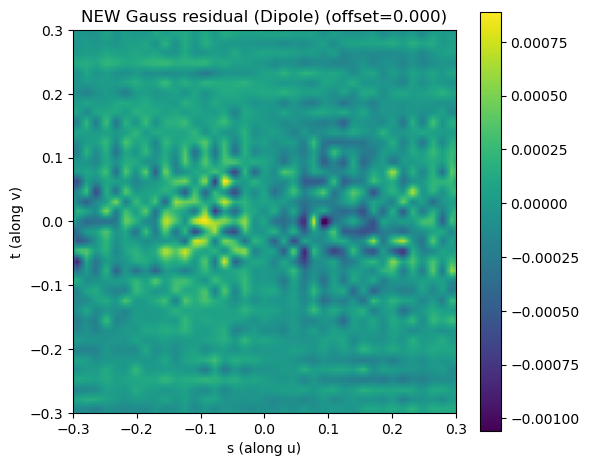

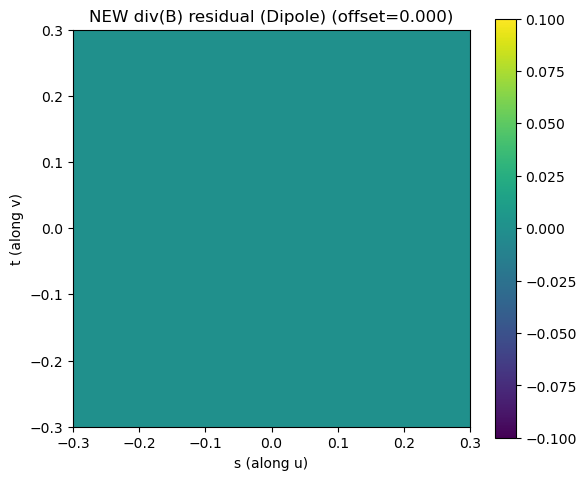

Done with new initial conditions.


In [6]:
# --- Re-run grid generation to fix variable conflict ---
# This re-defines X, Y, Z, KX, KY, KZ, etc. to be the correct (64,64,64) shape
n, L = 64, 1.0
(X, Y, Z), (KX, KY, KZ, K2), dx, L = make_grid(n=n, L=L)
print("Grid (X,Y,Z) reset to 64x64x64.")

# --- Initial Conditions: Electrostatic Dipole ---
print("Setting up Electrostatic Dipole...")

# Define two points for the dipole
x_pos, y_pos, z_pos = 0.5*L, 0.5*L, 0.55*L
x_neg, y_neg, z_neg = 0.5*L, 0.5*L, 0.45*L
sigma_dipole = 0.05*L

# Positive charge
# This line will now work, as X, Y, and Z are all (64,64,64)
r2_pos = (X-x_pos)**2 + (Y-y_pos)**2 + (Z-z_pos)**2
rho_pos = np.exp(-r2_pos/(2*sigma_dipole**2))

# Negative charge
r2_neg = (X-x_neg)**2 + (Y-y_neg)**2 + (Z-z_neg)**2
rho_neg = -np.exp(-r2_neg/(2*sigma_dipole**2))

# Total charge density
rho_new = rho_pos + rho_neg
# rho_new -= rho_new.mean() # Good practice, though already balanced

# No current
jx_new = np.zeros_like(X)
jy_new = np.zeros_like(X)
jz_new = np.zeros_like(X)

# --- Compute new fields and residuals ---
print("Computing new E and B fields...")
(Ex_new, Ey_new, Ez_new), (Bx_new, By_new, Bz_new) = compute_E_and_B(
    rho_new, jx_new, jy_new, jz_new, KX, KY, KZ, K2
)

print("Computing new residuals...")
divE_new = div_spectral(Ex_new, Ey_new, Ez_new, KX, KY, KZ)
divB_new = div_spectral(Bx_new, By_new, Bz_new, KX, KY, KZ)

gauss_residual_new = divE_new - rho_new/eps0
divB_new_field = divB_new

print("New residual norms (should be small):")
print(f"  ||div(E) - rho/eps0||_∞ = {float(np.abs(gauss_residual_new).max())}")
print(f"  ||div(B)||_∞            = {float(np.abs(divB_new_field).max())}")

# --- Plot the new residuals ---
print("Visualizing new residuals...")

# Slice through the dipole
point_vis = (0.5*L, 0.5*L, 0.5*L) 
normal_vis = (1.0, 0.0, 0.0)     # Slice along the yz-plane (to see the two charges)
offsets_vis = [0.0]

# Plot Gauss residual
visualize_residual_slices(
    gauss_residual_new,
    "NEW Gauss residual (Dipole)",
    point_vis, normal_vis, offsets_vis,
    width=0.6, npix=128, L=L
)

# Plot div(B) residual (should be zero since B is zero)
visualize_residual_slices(
    divB_new_field,
    "NEW div(B) residual (Dipole)",
    point_vis, normal_vis, offsets_vis,
    width=0.6, npix=128, L=L
)

print("Done with new initial conditions.")

Grid (X,Y,Z) reset to 64x64x64.
Setting up Magnetic Dipole...
Computing new E and B fields...
Computing new residuals...
New residual norms (should be small):
  ||div(E) - rho/eps0||_∞ = 0.0
  ||div(B)||_∞            = 2.6774719905385527e-20
Visualizing new residuals...


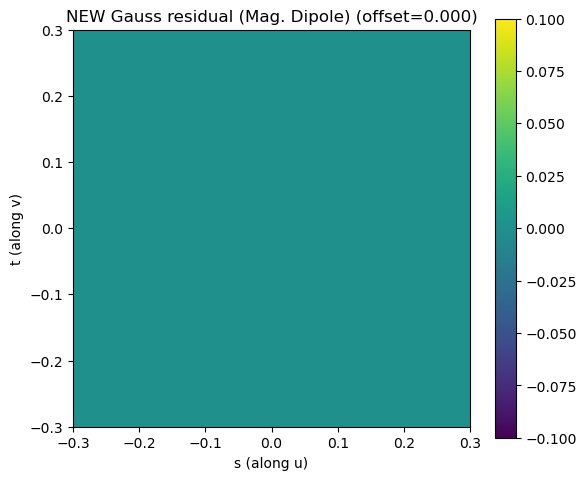

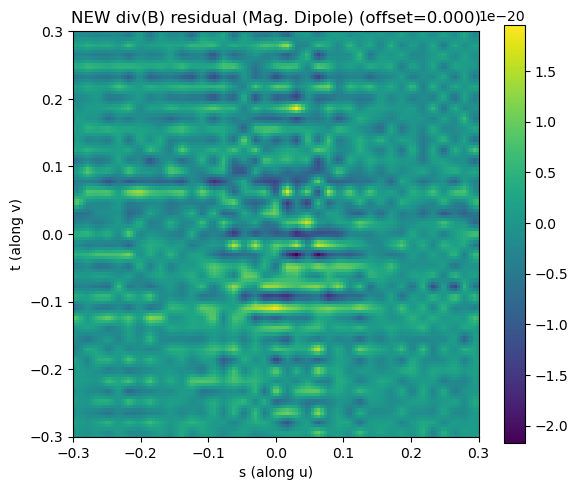

Done with Magnetic Dipole.


In [7]:
# --- Re-run grid generation to fix variable conflict ---
n, L = 64, 1.0
(X, Y, Z), (KX, KY, KZ, K2), dx, L = make_grid(n=n, L=L)
print("Grid (X,Y,Z) reset to 64x64x64.")

# --- Initial Conditions: Magnetic Dipole (Current Loop) ---
print("Setting up Magnetic Dipole...")

# No charge
rho_new = np.zeros_like(X)

# Define a scalar potential 'f' (a simple Gaussian)
x0, y0, z0 = 0.5*L, 0.5*L, 0.5*L
sigma_f = 0.1*L
r2_f = (X-x0)**2 + (Y-y0)**2 + (Z-z0)**2
f_potential = np.exp(-r2_f/(2*sigma_f**2))

# Compute j as the curl of F = (f_potential, 0, 0)
# This gives j = (0, -df/dz, df/dy)
# We use grad_spectral to get the derivatives
_, df_dy, df_dz = grad_spectral(f_potential, KX, KY, KZ)

jx_new = np.zeros_like(X)
jy_new = -df_dz
jz_new = df_dy

# --- Compute new fields and residuals ---
print("Computing new E and B fields...")
(Ex_new, Ey_new, Ez_new), (Bx_new, By_new, Bz_new) = compute_E_and_B(
    rho_new, jx_new, jy_new, jz_new, KX, KY, KZ, K2
)

print("Computing new residuals...")
divE_new = div_spectral(Ex_new, Ey_new, Ez_new, KX, KY, KZ)
divB_new = div_spectral(Bx_new, By_new, Bz_new, KX, KY, KZ)

gauss_residual_new = divE_new - rho_new/eps0
divB_new_field = divB_new

print("New residual norms (should be small):")
print(f"  ||div(E) - rho/eps0||_∞ = {float(np.abs(gauss_residual_new).max())}")
print(f"  ||div(B)||_∞            = {float(np.abs(divB_new_field).max())}")

# --- Plot the new residuals ---
print("Visualizing new residuals...")

# Slice through the current loop
point_vis = (0.5*L, 0.5*L, 0.5*L) 
normal_vis = (0.0, 1.0, 0.0)     # Slice along the xz-plane
offsets_vis = [0.0]

# Plot Gauss residual (should be zero since E is zero)
visualize_residual_slices(
    gauss_residual_new,
    "NEW Gauss residual (Mag. Dipole)",
    point_vis, normal_vis, offsets_vis,
    width=0.6, npix=128, L=L
)

# Plot div(B) residual
visualize_residual_slices(
    divB_new_field,
    "NEW div(B) residual (Mag. Dipole)",
    point_vis, normal_vis, offsets_vis,
    width=0.6, npix=128, L=L
)

print("Done with Magnetic Dipole.")

Grid (X,Y,Z) reset to 64x64x64.
Setting up Plane Waves...
Computing new E and B fields...
Computing new residuals...
New residual norms (should be small):
  ||div(E) - rho/eps0||_∞ = 0.0077972412109375
  ||div(B)||_∞            = 5.426075741208456e-20
Visualizing new residuals...


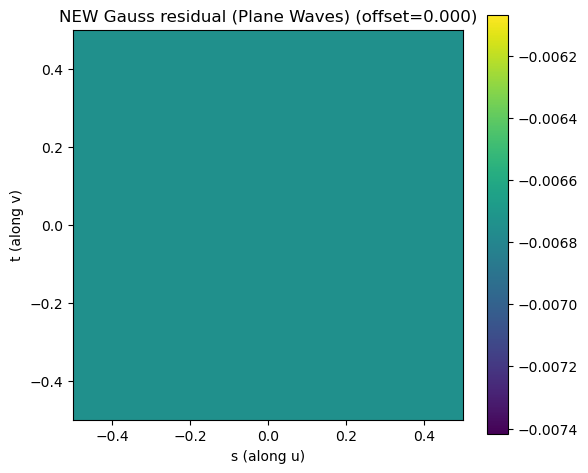

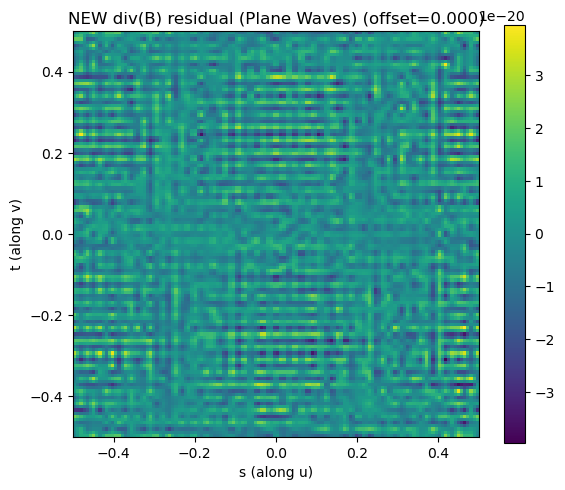

Done with Plane Waves.


In [8]:
# --- Re-run grid generation to fix variable conflict ---
n, L = 64, 1.0
(X, Y, Z), (KX, KY, KZ, K2), dx, L = make_grid(n=n, L=L)
print("Grid (X,Y,Z) reset to 64x64x64.")

# --- Initial Conditions: Plane Waves ---
print("Setting up Plane Waves...")

# Wavenumber for one full wave across the box
k = 2 * np.pi / L

# Charge density as a simple sine wave
rho_new = np.sin(k * X)
# rho_new -= rho_new.mean() # Already zero-mean

# Define a scalar potential 'g' for the current
g_potential = np.cos(k * Y) * np.cos(k * Z)

# Compute j as the curl of G = (0, 0, g_potential)
# This gives j = (dg/dy, -dg/dx, 0)
dg_dx, dg_dy, _ = grad_spectral(g_potential, KX, KY, KZ)

jx_new = dg_dy
jy_new = -dg_dx
jz_new = np.zeros_like(X)

# --- Compute new fields and residuals ---
print("Computing new E and B fields...")
(Ex_new, Ey_new, Ez_new), (Bx_new, By_new, Bz_new) = compute_E_and_B(
    rho_new, jx_new, jy_new, jz_new, KX, KY, KZ, K2
)

print("Computing new residuals...")
divE_new = div_spectral(Ex_new, Ey_new, Ez_new, KX, KY, KZ)
divB_new = div_spectral(Bx_new, By_new, Bz_new, KX, KY, KZ)

gauss_residual_new = divE_new - rho_new/eps0
divB_new_field = divB_new

print("New residual norms (should be small):")
print(f"  ||div(E) - rho/eps0||_∞ = {float(np.abs(gauss_residual_new).max())}")
print(f"  ||div(B)||_∞            = {float(np.abs(divB_new_field).max())}")

# --- Plot the new residuals ---
print("Visualizing new residuals...")

# Slice to see the wave patterns
point_vis = (0.25*L, 0.25*L, 0.25*L) # An arbitrary point
normal_vis = (1.0, 0.0, 0.0)     # Slice along the yz-plane
offsets_vis = [0.0]

# Plot Gauss residual
visualize_residual_slices(
    gauss_residual_new,
    "NEW Gauss residual (Plane Waves)",
    point_vis, normal_vis, offsets_vis,
    width=L, npix=128, L=L # Use full width L to see the waves
)

# Plot div(B) residual
visualize_residual_slices(
    divB_new_field,
    "NEW div(B) residual (Plane Waves)",
    point_vis, normal_vis, offsets_vis,
    width=L, npix=128, L=L # Use full width L
)

print("Done with Plane Waves.")

In [9]:
import time
from numpy.fft import fftn, ifftn

def helmholtz_project_B(Bx,By,Bz, KX,KY,KZ,K2):
    # forward
    Bxk = fftn(Bx); Byk = fftn(By); Bzk = fftn(Bz)
    kdotB = KX*Bxk + KY*Byk + KZ*Bzk
    mask = (K2 != 0)
    Bxk[mask] = Bxk[mask] - (KX[mask]*kdotB[mask])/K2[mask]
    Byk[mask] = Byk[mask] - (KY[mask]*kdotB[mask])/K2[mask]
    Bzk[mask] = Bzk[mask] - (KZ[mask]*kdotB[mask])/K2[mask]
    Bx_new = np.real(ifftn(Bxk))
    By_new = np.real(ifftn(Byk))
    Bz_new = np.real(ifftn(Bzk))
    return Bx_new, By_new, Bz_new

def enforce_Gauss_E(Ex,Ey,Ez,rho,KX,KY,KZ,K2,eps0=8.8541878128e-12):
    # forward E and rho
    Exk = fftn(Ex); Eyk = fftn(Ey); Ezk = fftn(Ez)
    rhok = fftn(rho)
    kdotE = 1j*(KX*Exk + KY*Eyk + KZ*Ezk)   # i k·E_k
    mask = (K2 != 0)
    phi_k = np.zeros_like(kdotE)
    phi_k[mask] = (kdotE[mask] - rhok[mask]/eps0)/(-K2[mask])
    # grad phi in k-space
    gradphi_x_k = 1j*KX * phi_k
    gradphi_y_k = 1j*KY * phi_k
    gradphi_z_k = 1j*KZ * phi_k
    # inverse
    gradphi_x = np.real(ifftn(gradphi_x_k))
    gradphi_y = np.real(ifftn(gradphi_y_k))
    gradphi_z = np.real(ifftn(gradphi_z_k))
    Ex_new = Ex - gradphi_x
    Ey_new = Ey - gradphi_y
    Ez_new = Ez - gradphi_z
    return Ex_new, Ey_new, Ez_new

# diagnostic helper
def residual_norms(Ex,Ey,Ez,Bx,By,Bz,rho,KX,KY,KZ,K2,eps0=8.8541878128e-12):
    divE = div_spectral(Ex,Ey,Ez,KX,KY,KZ)
    divB = div_spectral(Bx,By,Bz,KX,KY,KZ)
    gauss = divE - rho/eps0
    return float(np.abs(gauss).max()), float(np.abs(divB).max())

# Usage:
t0=time.perf_counter()
Ex_p,Ey_p,Ez_p = enforce_Gauss_E(Ex,Ey,Ez,rho,KX,KY,KZ,K2)
Bx_p,By_p,Bz_p = helmholtz_project_B(Bx,By,Bz,KX,KY,KZ,K2)
t1=time.perf_counter()
print("Before:", residual_norms(Ex,Ey,Ez,Bx,By,Bz,rho,KX,KY,KZ,K2))
print("After: ", residual_norms(Ex_p,Ey_p,Ez_p,Bx_p,By_p,Bz_p,rho,KX,KY,KZ,K2))
print("Projection time (s):", t1-t0)


Before: (203558421628.03958, 238.6567674779619)
After:  (13087848547.055302, 10.354751113118246)
Projection time (s): 0.4511864999658428


In [10]:
# === benchmarking_and_plots.py ===
import numpy as np, time, matplotlib.pyplot as plt
from numpy.fft import fftn, ifftn

# paste your utility functions here: make_grid, grad_spectral, curl_spectral, div_spectral,
# solve_phi_from_rho, solve_A_from_j, compute_E_and_B, sample_plane, visualize_residual_slices, etc.
# Also paste the combined_project_exact function from earlier.

def bench_one_case(n, L=1.0, do_plots=False):
    (X,Y,Z), (KX,KY,KZ,K2), dx, L = make_grid(n=n, L=L)
    # build rho and j like your cell1 but scaled small so rho/eps0 isn't astronomic for display:
    sigma = 0.10*L
    x0,y0,z0 = 0.5*L,0.5*L,0.5*L
    r2 = (X-x0)**2 + (Y-y0)**2 + (Z-z0)**2
    rho = np.exp(-r2/(2*sigma**2))
    rho -= rho.mean()

    # current for compute_E_and_B (use your earlier f->j construction)
    f = np.exp(-r2/(2*(0.12*L)**2))
    fx, fy, fz = grad_spectral(f, KX, KY, KZ)
    jx, jy, jz = fy, -fx, np.zeros_like(f)

    # --- potential-based init timing ---
    t0=time.perf_counter()
    (Ex_pot, Ey_pot, Ez_pot), (Bx_pot, By_pot, Bz_pot) = compute_E_and_B(rho, jx, jy, jz, KX, KY, KZ, K2)
    t1=time.perf_counter()
    pot_time = t1 - t0
    pot_res = residual_norms(Ex_pot, Ey_pot, Ez_pot, Bx_pot, By_pot, Bz_pot, rho, KX, KY, KZ, K2)

    # --- random-init + projection timing ---
    # smooth random fields
    rng = np.random.default_rng(123)
    def smooth_random():
        F = fftn(rng.standard_normal((n,n,n)))
        LP = np.exp(-K2 / (2.0*(0.35*np.sqrt(K2.max()))**2))
        return np.real(ifftn(F * LP))
    Ex_rand = smooth_random(); Ey_rand = smooth_random(); Ez_rand = smooth_random()
    Bx_rand = smooth_random(); By_rand = smooth_random(); Bz_rand = smooth_random()

    t0=time.perf_counter()
    Ex_proj, Ey_proj, Ez_proj, Bx_proj, By_proj, Bz_proj, summary = combined_project_exact(
        Ex_rand, Ey_rand, Ez_rand, Bx_rand, By_rand, Bz_rand, rho, KX, KY, KZ, K2, debug=False)
    t1=time.perf_counter()
    proj_time = t1 - t0
    proj_res = residual_norms(Ex_proj, Ey_proj, Ez_proj, Bx_proj, By_proj, Bz_proj, rho, KX, KY, KZ, K2)

    # optional visualize center slices
    if do_plots:
        point = (0.5*L,0.5*L,0.5*L)
        normal = (1.0, 0.6, 0.3)
        offsets = [-0.15, 0.0, 0.15]
        visualize_residual_slices(pot_residual_field := div_spectral(Ex_pot,Ey_pot,Ez_pot,KX,KY,KZ)-rho/8.8541878128e-12,
                                  "Pot Gauss residual", point, normal, offsets, width=0.6, npix=256, L=L)
        visualize_residual_slices(div_spectral(Bx_pot,By_pot,Bz_pot,KX,KY,KZ),
                                  "Pot divB", point, normal, offsets, width=0.6, npix=256, L=L)

    return {
        "n":n,"N":n**3,
        "pot_time":pot_time, "pot_res":pot_res,
        "proj_time":proj_time, "proj_res":proj_res
    }

# Run benchmark for n,2n,4n (choose safe n0)
n0 = 32   # change to 64 if your machine allows
cases = [n0, 2*n0, 4*n0]
results=[]

for ni in cases:
    print("Running case n=",ni)
    r = bench_one_case(ni, do_plots=False)
    results.append(r)
    print(" -> done:", r)

# Make timing plot and table
ns = [r["n"] for r in results]
times_pot = [r["pot_time"] for r in results]
times_proj = [r["proj_time"] for r in results]

plt.figure()
plt.loglog([r["N"] for r in results], times_pot, 'o-', label='potential init')
plt.loglog([r["N"] for r in results], times_proj, 's-', label='random+projection')
plt.xlabel('N = n^3'); plt.ylabel('time (s)')
plt.legend(); plt.title('Timing scaling'); plt.grid(True)
plt.show()

# Print table
import pandas as pd
df = pd.DataFrame(results)
print(df[["n","N","pot_time","proj_time","pot_res","proj_res"]])
# Save table
df.to_csv("benchmark_results.csv", index=False)


Running case n= 32


NameError: name 'combined_project_exact' is not defined